In [112]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.cluster import KMeans 
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

In [113]:
#Loading the dataset
df=pd.DataFrame(pd.read_csv('Mall_Customers - Mall_Customers.csv'))

In [114]:
# Shape of Dataset
df.shape

(200, 5)

In [115]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [116]:
#Datatypes in dataset
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [117]:
#Describing the data
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [118]:
#number of zeros
(df==0).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [119]:
#Check for Null Values
(df.isnull()).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [120]:
df=df.drop(columns=['CustomerID'])

In [121]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [122]:
df.mean(numeric_only=True)

Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

In [123]:
df.median(numeric_only=True)

Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

In [124]:
df.mode(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
0,32.0,54,42.0
1,NaN,78,NaN


In [125]:
df.std(numeric_only=True)

Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

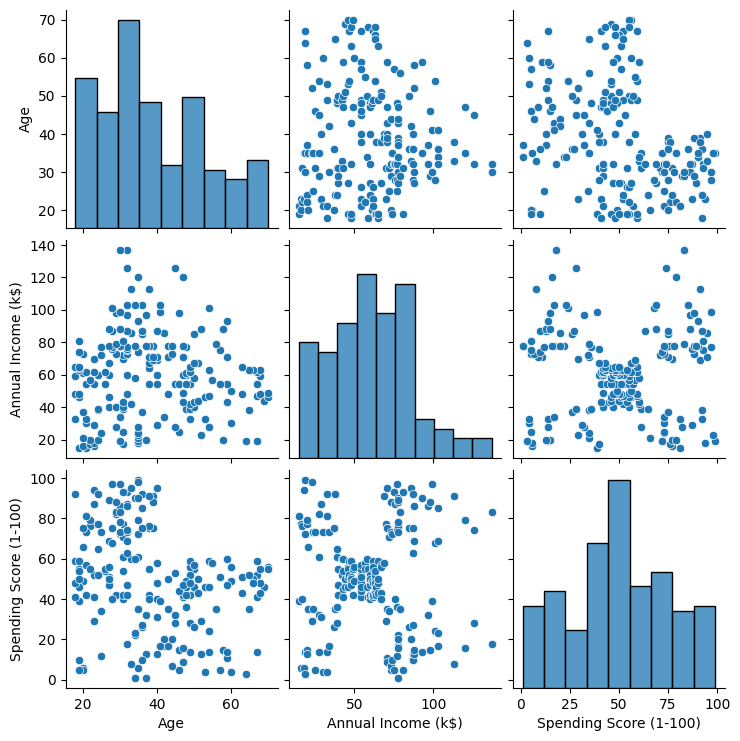

In [126]:
 sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Count'>

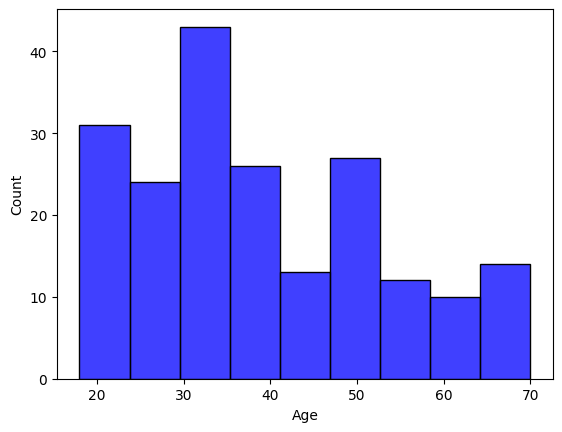

In [127]:
sns.histplot(df,x='Age',color='blue')

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

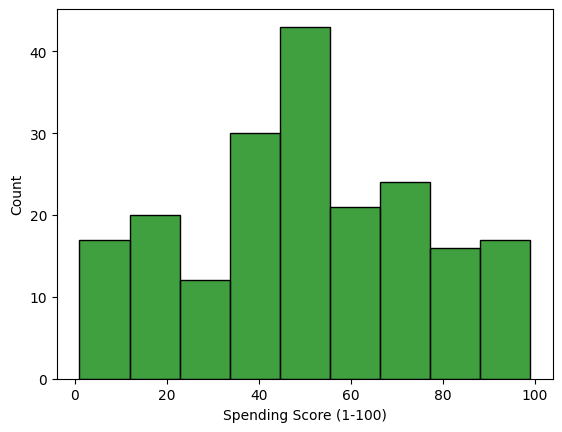

In [128]:
sns.histplot(df,x='Spending Score (1-100)',color='green')

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

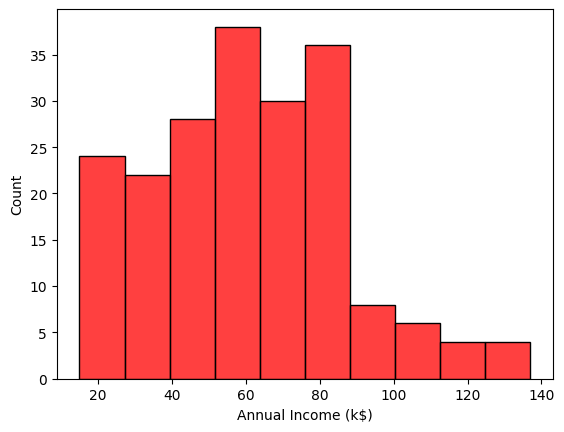

In [129]:
sns.histplot(df,x='Annual Income (k$)',color='red')

<Axes: xlabel='Spending Score (1-100)', ylabel='count'>

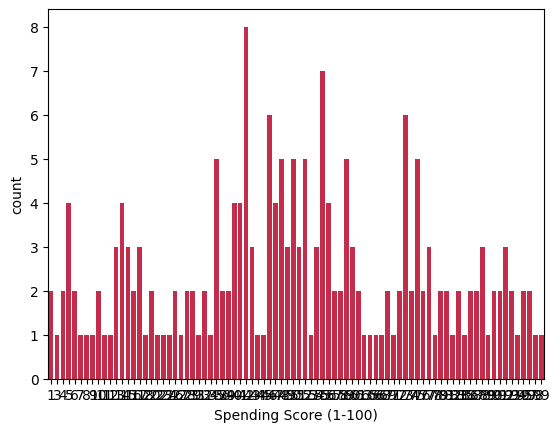

In [130]:
sns.countplot(data=df,x=df['Spending Score (1-100)'],color='crimson')

<Axes: >

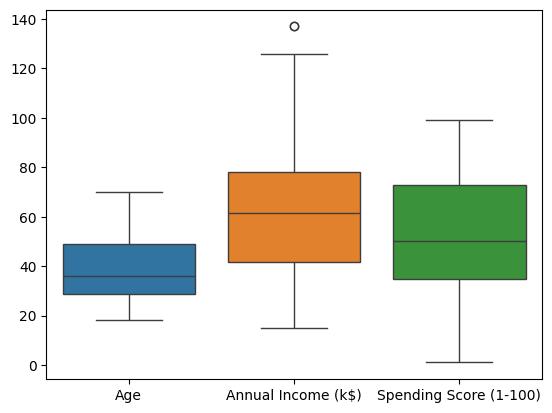

In [131]:
sns.boxplot(data=df)

In [132]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

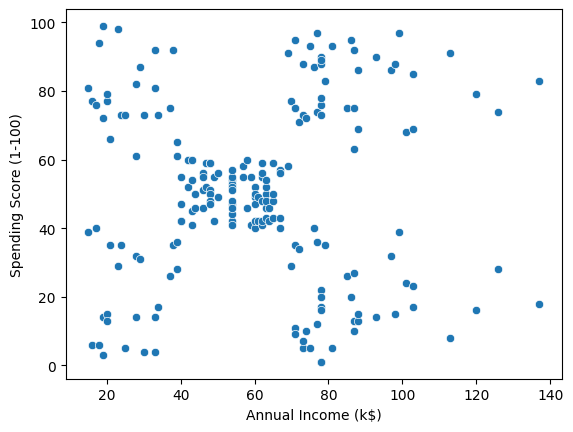

In [133]:
sns.scatterplot(data=X,x='Annual Income (k$)',y='Spending Score (1-100)')

In [134]:
kmeans=KMeans(n_clusters=3)

In [135]:
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [136]:
cluster=kmeans.predict(X)

In [137]:
kmeans.cluster_centers_

array([[44.15447154, 49.82926829],
       [87.        , 18.63157895],
       [86.53846154, 82.12820513]])

In [138]:
kmeans.inertia_

106348.37306211119

In [139]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

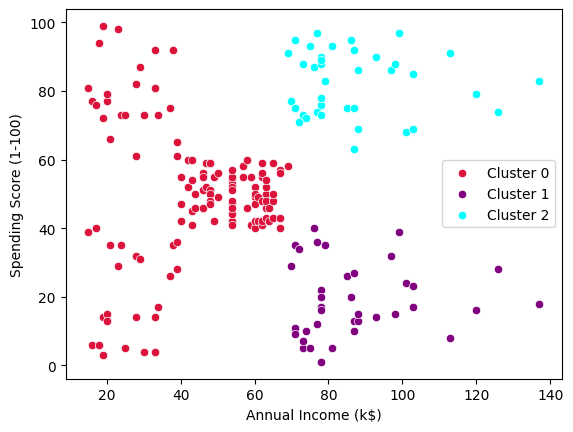

In [140]:
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 0',color='crimson')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 1',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 2',color='cyan')

In [141]:
wcss= []
for k in range (1,16):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
wcss   

[269981.28,
 185917.14253928524,
 106348.37306211119,
 82472.19413919415,
 44448.45544793371,
 38813.77233183483,
 34222.27061887388,
 31828.408760702812,
 21862.09267218289,
 21833.587515597508,
 18128.682415772633,
 16847.846594324146,
 15331.744552452745,
 13671.460663588216,
 12456.29647313471]

<Axes: >

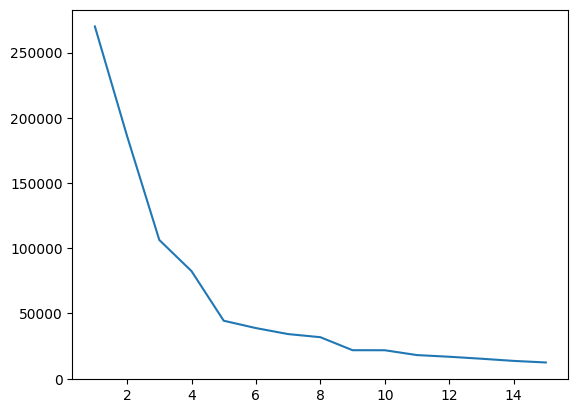

In [142]:
sns.lineplot(x=list(range(1,16)),y=wcss)

In [143]:
kmeans=KMeans(n_clusters=5)

In [144]:
kmeans.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [145]:
cluster=kmeans.predict(X)

In [146]:
kmeans.cluster_centers_

array([[86.53846154, 82.12820513],
       [87.75      , 17.58333333],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [55.0875    , 49.7125    ]])

In [147]:
kmeans.inertia_

44454.47647967974

In [148]:
kmeans.labels_

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 4,
       2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 1, 0, 4, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

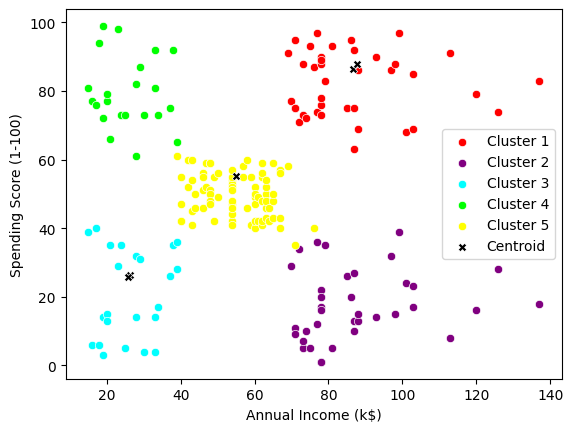

In [149]:
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 1',color='red')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 2',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 3',color='cyan')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==3],y=X['Spending Score (1-100)'][kmeans.labels_==3],label='Cluster 4',color='lime')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==4],y=X['Spending Score (1-100)'][kmeans.labels_==4],label='Cluster 5',color='yellow')
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,0],label='Centroid',marker='X',color='black')

Enter annual Income 100
Enter spending score 120


Entered point is in  1


C:\Users\ARJUN\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


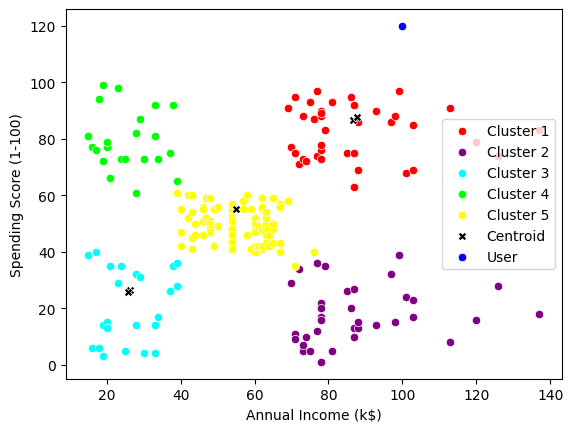

In [150]:
A_I=int(input('Enter annual Income'))
S_S=int(input('Enter spending score'))
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 1',color='red')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 2',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 3',color='cyan')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==3],y=X['Spending Score (1-100)'][kmeans.labels_==3],label='Cluster 4',color='lime')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==4],y=X['Spending Score (1-100)'][kmeans.labels_==4],label='Cluster 5',color='yellow')
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,0],label='Centroid',marker='X',color='black')
sns.scatterplot(x=[A_I],y=[S_S],color='blue',label='User')
print("Entered point is in ",(kmeans.predict([[A_I,S_S]]))[0]+1)

In [151]:
cluster= AgglomerativeClustering().fit(X)

In [152]:
cluster

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [153]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [154]:
sns.clustermap(cluster)

ValueError: DataFrame constructor not properly called!

In [155]:
df = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
df['Cluster'] = cluster.labels_

In [156]:
df

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,1
1,15,81,1
2,16,6,1
3,16,77,1
4,17,40,1
...,...,...,...
195,120,79,0
196,126,28,0
197,126,74,0
198,137,18,0


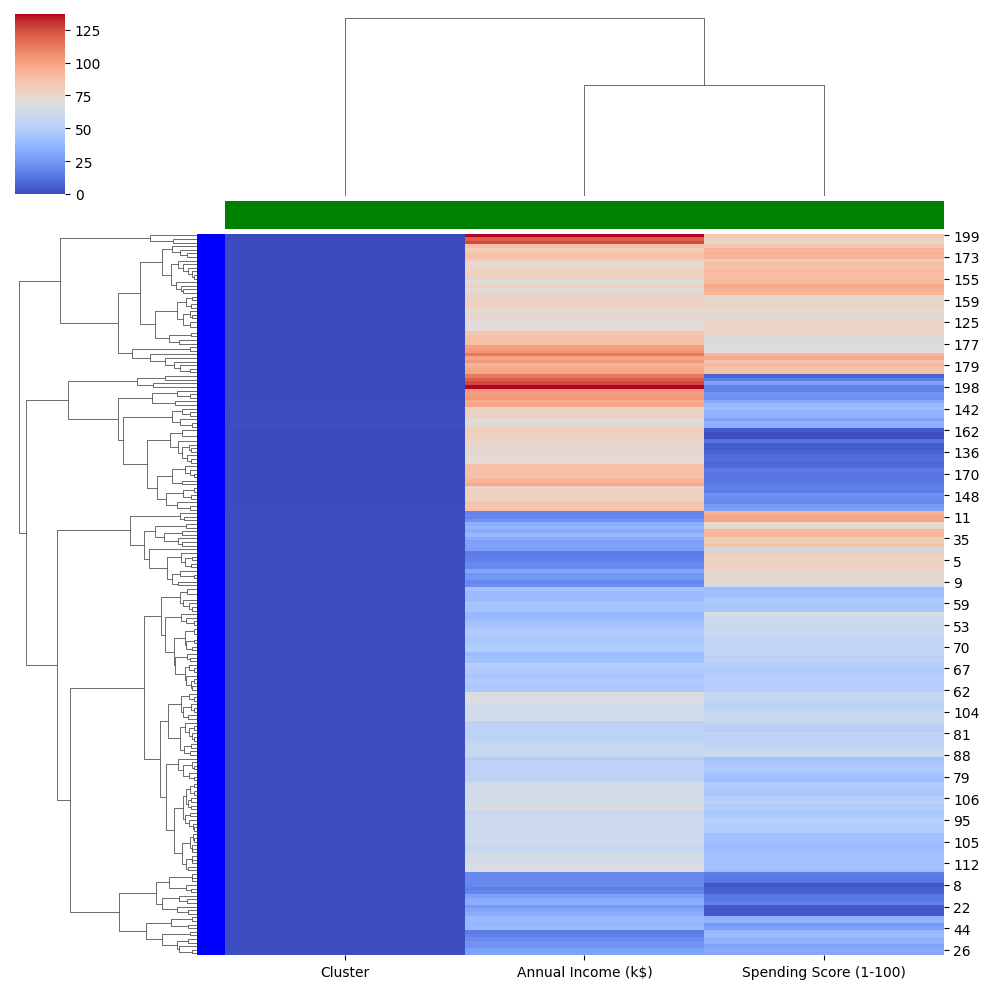

In [163]:
sns.clustermap(df,row_colors=['blue']*len(df),col_colors=['green']*len(df.columns),cmap='coolwarm')